# `01_langgraph_basic.ipynb`

`uv add langgraph langchain`

## Core Concept
1. `state` -> 노드들을 관통하는 데이터
1. Langgraph 기획 -> 노드/엣지 그림 + State에 어떤 데이터를 담을지를 기획하는 것

### 예시 - 여행 계획 세워주는 Workflow
1. wf가 채워야 하는 정보
    - 목적지: `str`
    - 여행일수: `int`
    - 목적지에서 방문할 장소들: `list[str]`
2. Node - Edge
    1. 목적지 채우는 Node
    2. 여행일수 Node
    3. 방문할 장소 채우는 Node
    4. 최종 답변을 만들어주는 LLM Node


In [28]:
from dotenv import load_dotenv
from typing_extensions import TypedDict, List
from langgraph.graph import StateGraph, START, END
from langchain.chat_models import init_chat_model

load_dotenv()

True

In [18]:
# State 정의 -> 이름 잘짓기
class TripState(TypedDict):  # TypedDict? 딕셔너리(k-v)인데, Value의 자료형을 미리 정해놓은 dict
    message: str          # 사용자 입력메세지 - 시작과 동시에 채워질 데이터
    destination: str      # 목적지
    days: int             # 여행일수
    places: List[str]     # 방문장소목록 ex. ['경복궁', 'N타워', '한강']
    answer: str           # 최종 답변 - 종료시 완성될 메세지

In [32]:
# Node 정의 (함수)

def set_destination_node(state: TripState):
    import random
    pick = random.choice(['서울', '부산', '제주'])
    # Langgraph가 State 바뀐 부분만 넘기면, 자동으로 전체 + 갱신해서 넘김 (Partial Update 기능 지원)
    return {'destination': pick}


def set_days_node(state: TripState):
    return {'days': 3}


def collect_places_node(state: TripState):
    # state에서 정보를 뽑을것
    d = state['destination']

    if d == '서울':
        places = ['광화문', '국중박', '한강', 'N타워']
    elif d == '부산':
        places = ['해운대', '광안리', '서면', '기장']
    elif d == '제주':
        places = ['중문', '우도', '협재']

    return {'places': places}


def make_answer_node(state: TripState):
    destination = state['destination']
    days = state['days']
    places = state['places']

    llm = init_chat_model('openai:gpt-4.1-mini')
    # 같은 일을 하는데, 방법이 여러개
    # import는 위로 보내기
    from langchain.messages import HumanMessage, SystemMessage, AIMessage
    ai_message = llm.invoke([
        # 메세지 1 (dict방법)
        {'role': 'system', 'content': '너는 여행계획을 짜주는 어시스턴트야.'},
        # 메세지 2 (Human, AI, System 메세지 만들기)
        HumanMessage(content=f'{destination}에 {days}일동안 {places}를 갈거야.'),
    ])

    return {'answer': ai_message.content}

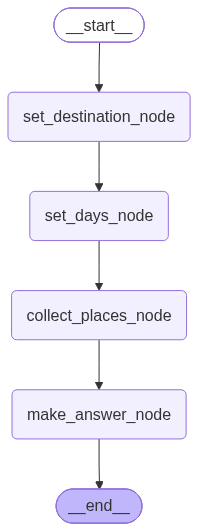

In [35]:
# builder 에서 Node들 연결 = 조립
builder = StateGraph(TripState)  # TripState 를 공유하는 Graph 빌더

# Node 등록 (이름, 노드(함수))
builder.add_node('set_destination_node', set_destination_node)
builder.add_node('collect_places_node', collect_places_node)
builder.add_node('set_days_node', set_days_node)
builder.add_node('make_answer_node', make_answer_node)

# Edge 연결 - 노드끼리 연결
builder.add_edge(START, 'set_destination_node')
builder.add_edge('set_destination_node', 'set_days_node')
builder.add_edge('set_days_node', 'collect_places_node')
builder.add_edge('collect_places_node', 'make_answer_node')
builder.add_edge('make_answer_node', END)

# graph 컴파일 (실행 가능하게 만든다)
graph = builder.compile()
graph

In [34]:
# Langchain 세상에서 "실행" 은 .invoke() 가 기본 메서드
res_state = graph.invoke({  # Typed DICT니까, dict 를 시작시 넣기
    'message': '나 여행가고 싶어'  # 최초에 채울 k-v
})

print(res_state['answer'])

부산 3일 여행 일정 추천해드릴게요!

### 1일차: 해운대
- 오전: 해운대 해수욕장 산책 및 해변 카페에서 아침
- 점심: 해운대 시장에서 씨앗호떡, 어묵 등 길거리 음식 즐기기
- 오후: 해운대 달맞이길 드라이브 및 누리마루 APEC 하우스 방문
- 저녁: 해운대 앞 바닷가에서 석양 감상 후 해운대 맛집에서 저녁 식사

### 2일차: 광안리 + 서면
- 오전: 광안리 해변에서 산책 및 광안대교 전망 즐기기
- 점심: 광안리 주변 카페나 해산물 맛집에서 식사
- 오후: 서면으로 이동해 쇼핑과 카페거리 탐방
- 저녁: 서면에서 다양한 길거리 음식 혹은 맛집 방문 후 야시장 체험

### 3일차: 기장
- 오전: 기장 대변항 방문해 신선한 해산물 시장 구경
- 점심: 기장 멸치국수, 해물탕 등 현지 음식 체험
- 오후: 해동 용궁사 방문 후 기장 해안 드라이브
- 저녁: 기장에서 여유롭게 마무리 후 부산 도심으로 이동

필요하면 각 장소별 추천 맛집이나 교통편도 알려드릴게요!
